<a href="https://colab.research.google.com/github/prkalva10/Collab/blob/main/Analise_Dados_FINAL_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Análise de Dados - Aula final**

**Perguntas a responder:**

1.   Qual é a tendência de volume de pedidos da Olist ao longo do tempo?
2.   Como o custo médio do frete varia geograficamente pelo Brasil?
3.   Qual é o impacto real e quantificável da demora na entrega sobre a nota de satisfação do cliente?
4.   Quais categorias de produto do catálogo mais puxam a satisfação para baixo e sofrem com a complexidade logística?

Roteiro:

*   Passo 1: Obtenção e leitura dos dados (Kaggle)
*   Passo 2: Limpeza e Qualidade de dados (Tratamento de nulos e duplicatas)
*   Passo 3: Modelagem de dados (União das tabelas via merga)
*   Passo 4: Feature Engineering (Criação de métricas de atraso, SLAs e geográficas)
*   Passo 5: Exportação da base otimizada para BI (Looker Studio)














In [1]:
# Passo 1 - Obtenção dos dados no kaggle

import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [2]:
# Outras importações que serão usadas:

import pandas as pd
import numpy as np

In [3]:
# Vamos carregar os dataframes que estão na pasta do kaggle

df_orders = pd.read_csv(path + '/olist_orders_dataset.csv')
df_items = pd.read_csv(path + '/olist_order_items_dataset.csv')
df_customers = pd.read_csv(path + '/olist_customers_dataset.csv')
df_reviews = pd.read_csv(path + '/olist_order_reviews_dataset.csv')
df_products = pd.read_csv(path + '/olist_products_dataset.csv')


In [4]:
# Tradução das colunas para ficar mais fácil e claro

map_orders = {'order_id': 'id_pedido',
              'customer_id': 'id_cliente',
              'order_status': 'status_pedido',
              'order_purchase_timestamp': 'data_compra',
              'order_approved_at': 'data_aprovacao',
              'order_delivered_carrier_date': 'data_envio_transportadora',
              'order_delivered_customer_date': 'data_entrega_cliente',
              'order_estimated_delivery_date': 'data_entrega_estimada'
              }
df_orders.rename(columns=map_orders, inplace=True)
df_orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   id_pedido                  99441 non-null  object
 1   id_cliente                 99441 non-null  object
 2   status_pedido              99441 non-null  object
 3   data_compra                99441 non-null  object
 4   data_aprovacao             99281 non-null  object
 5   data_envio_transportadora  97658 non-null  object
 6   data_entrega_cliente       96476 non-null  object
 7   data_entrega_estimada      99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:

map_items = { 'order_id': 'id_pedido',
              'product_id': 'id_produto',
              'seller_id': 'id_vendedor',
              'shipping_limit_date': 'data_limite_envio',
              'price': 'preco_produto',
              'freight_value': 'valor_frete'
            }
df_items.rename(columns=map_items, inplace=True)

df_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_pedido          112650 non-null  object 
 1   order_item_id      112650 non-null  int64  
 2   id_produto         112650 non-null  object 
 3   id_vendedor        112650 non-null  object 
 4   data_limite_envio  112650 non-null  object 
 5   preco_produto      112650 non-null  float64
 6   valor_frete        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [6]:
map_customers = {'customer_id': 'id_cliente',
                 'customer_city': 'cidade_cliente',
                 'customer_state': 'estado_cliente'
                 }
df_customers.rename(columns=map_customers, inplace=True)

df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id_cliente                99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   cidade_cliente            99441 non-null  object
 4   estado_cliente            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [7]:

map_reviews = {'order_id': 'id_pedido',
               'review_score': 'nota_avaliacao',
               }
df_reviews.rename(columns=map_reviews, inplace=True)

df_reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   id_pedido                99224 non-null  object
 2   nota_avaliacao           99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [8]:
map_products = {'product_id': 'id_produto',
                'product_category_name': 'categoria_produto'
                }
df_products.rename(columns=map_products, inplace=True)

df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_produto                  32951 non-null  object 
 1   categoria_produto           32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**LIMPEZA de dados**

In [9]:
df_orders.head()

,id_pedido,id_cliente,status_pedido,data_compra,data_aprovacao,data_envio_transportadora,data_entrega_cliente,data_entrega_estimada
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
# Queremos somente os pedidos ENTREGUES - delivered

df_orders = df_orders[df_orders['status_pedido'] == 'delivered']
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   id_pedido                  96478 non-null  object
 1   id_cliente                 96478 non-null  object
 2   status_pedido              96478 non-null  object
 3   data_compra                96478 non-null  object
 4   data_aprovacao             96464 non-null  object
 5   data_envio_transportadora  96476 non-null  object
 6   data_entrega_cliente       96470 non-null  object
 7   data_entrega_estimada      96478 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [11]:
# Transformar as datas para DateTime - df_orders

date_cols_orders = ["data_compra","data_aprovacao","data_envio_transportadora","data_entrega_cliente","data_entrega_estimada"]
for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_pedido                  96478 non-null  object        
 1   id_cliente                 96478 non-null  object        
 2   status_pedido              96478 non-null  object        
 3   data_compra                96478 non-null  datetime64[ns]
 4   data_aprovacao             96464 non-null  datetime64[ns]
 5   data_envio_transportadora  96476 non-null  datetime64[ns]
 6   data_entrega_cliente       96470 non-null  datetime64[ns]
 7   data_entrega_estimada      96478 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [12]:
# Transformar as datas para DateTime - df_items

df_items["data_limite_envio"] = pd.to_datetime(df_items["data_limite_envio"])
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id_pedido          112650 non-null  object        
 1   order_item_id      112650 non-null  int64         
 2   id_produto         112650 non-null  object        
 3   id_vendedor        112650 non-null  object        
 4   data_limite_envio  112650 non-null  datetime64[ns]
 5   preco_produto      112650 non-null  float64       
 6   valor_frete        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [13]:
# Reviews - Média por pedido - não vamos analisar itens dai se tiver mais de um item será a média dos itens.

df_reviews_clean = df_reviews.groupby('id_pedido', as_index=False)['nota_avaliacao'].mean()
df_reviews_clean

,id_pedido,nota_avaliacao
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [14]:
df_reviews_clean.describe()

,nota_avaliacao
count,98673.000000
mean,4.086793
std,1.346274
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [15]:
# Não queremos nada NULL, vamos olhar para o Non-Null Count em todos do dataframes

df_reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98673 entries, 0 to 98672
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_pedido       98673 non-null  object 
 1   nota_avaliacao  98673 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.5+ MB


In [16]:
# Não queremos nada NULL
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id_cliente                99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   cidade_cliente            99441 non-null  object
 4   estado_cliente            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [17]:
# Nossos DataFrames
# df_reviews_clean.info()
# df_customers.info()
# df_orders.info()
# df_items.info()
# df_products.info()

**MERGE das tabelas**

In [18]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id_cliente                99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   cidade_cliente            99441 non-null  object
 4   estado_cliente            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [19]:
df_main = df_orders.merge(df_customers[['id_cliente','cidade_cliente','estado_cliente']], on='id_cliente', how='left')
df_main

,id_pedido,id_cliente,status_pedido,data_compra,data_aprovacao,data_envio_transportadora,data_entrega_cliente,data_entrega_estimada,cidade_cliente,estado_cliente
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,sao jose dos campos,SP
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,praia grande,SP
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,nova vicosa,BA
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,japuiba,RJ


In [20]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id_pedido          112650 non-null  object        
 1   order_item_id      112650 non-null  int64         
 2   id_produto         112650 non-null  object        
 3   id_vendedor        112650 non-null  object        
 4   data_limite_envio  112650 non-null  datetime64[ns]
 5   preco_produto      112650 non-null  float64       
 6   valor_frete        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [21]:
df_main = df_main.merge(df_items[['id_pedido','id_produto','id_vendedor','preco_produto','valor_frete','data_limite_envio']],
                        on='id_pedido', how='left')

df_main

,id_pedido,id_cliente,status_pedido,data_compra,data_aprovacao,data_envio_transportadora,data_entrega_cliente,data_entrega_estimada,cidade_cliente,estado_cliente,id_produto,id_vendedor,preco_produto,valor_frete,data_limite_envio
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,2017-11-23 19:45:59
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,2018-02-19 20:31:37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,praia grande,SP,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,174.90,20.10,2018-02-12 13:10:37
110193,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,nova vicosa,BA,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,205.99,65.02,2017-09-05 15:04:16
110194,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,japuiba,RJ,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,2018-01-12 21:36:21
110195,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,japuiba,RJ,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,2018-01-12 21:36:21


In [22]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_produto                  32951 non-null  object 
 1   categoria_produto           32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [23]:
df_main = df_main.merge(df_products[['id_produto','categoria_produto']], on='id_produto', how='left')

In [24]:
df_reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98673 entries, 0 to 98672
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_pedido       98673 non-null  object 
 1   nota_avaliacao  98673 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.5+ MB


In [25]:
df_main = df_main.merge(df_reviews_clean, on='id_pedido', how='left')

In [26]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_pedido                  110197 non-null  object        
 1   id_cliente                 110197 non-null  object        
 2   status_pedido              110197 non-null  object        
 3   data_compra                110197 non-null  datetime64[ns]
 4   data_aprovacao             110182 non-null  datetime64[ns]
 5   data_envio_transportadora  110195 non-null  datetime64[ns]
 6   data_entrega_cliente       110189 non-null  datetime64[ns]
 7   data_entrega_estimada      110197 non-null  datetime64[ns]
 8   cidade_cliente             110197 non-null  object        
 9   estado_cliente             110197 non-null  object        
 10  id_produto                 110197 non-null  object        
 11  id_vendedor                110197 non-null  object  

In [27]:
# data_entrega_cliente tem registros nulos, como é pouco (110197 - 110189 = 8 registros) vamos dropar
110197 - 110189

8

In [28]:
# dropar os registros cujo cammpo 'data_entrega_cliente' é nulo

df_main.dropna(subset=['data_entrega_cliente'], inplace=True)
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 110196
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_pedido                  110189 non-null  object        
 1   id_cliente                 110189 non-null  object        
 2   status_pedido              110189 non-null  object        
 3   data_compra                110189 non-null  datetime64[ns]
 4   data_aprovacao             110174 non-null  datetime64[ns]
 5   data_envio_transportadora  110188 non-null  datetime64[ns]
 6   data_entrega_cliente       110189 non-null  datetime64[ns]
 7   data_entrega_estimada      110189 non-null  datetime64[ns]
 8   cidade_cliente             110189 non-null  object        
 9   estado_cliente             110189 non-null  object        
 10  id_produto                 110189 non-null  object        
 11  id_vendedor                110189 non-null  object       

Dados prontos para a **FEATURE Engineering**

In [29]:
# Criar Features

df_main['tempo_entrega_dias'] = (df_main['data_entrega_cliente'] - df_main['data_compra']).dt.days
df_main['atrazo_entrega_dias'] = (df_main['data_entrega_cliente'] - df_main['data_entrega_estimada']).dt.days
df_main.head()

,id_pedido,id_cliente,status_pedido,data_compra,data_aprovacao,data_envio_transportadora,data_entrega_cliente,data_entrega_estimada,cidade_cliente,estado_cliente,id_produto,id_vendedor,preco_produto,valor_frete,data_limite_envio,categoria_produto,nota_avaliacao,tempo_entrega_dias,atrazo_entrega_dias
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,utilidades_domesticas,4.0,8,-8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27,perfumaria,4.0,13,-6
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23,automotivo,5.0,9,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,2017-11-23 19:45:59,pet_shop,5.0,13,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,2018-02-19 20:31:37,papelaria,5.0,2,-10


In [30]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 110196
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_pedido                  110189 non-null  object        
 1   id_cliente                 110189 non-null  object        
 2   status_pedido              110189 non-null  object        
 3   data_compra                110189 non-null  datetime64[ns]
 4   data_aprovacao             110174 non-null  datetime64[ns]
 5   data_envio_transportadora  110188 non-null  datetime64[ns]
 6   data_entrega_cliente       110189 non-null  datetime64[ns]
 7   data_entrega_estimada      110189 non-null  datetime64[ns]
 8   cidade_cliente             110189 non-null  object        
 9   estado_cliente             110189 non-null  object        
 10  id_produto                 110189 non-null  object        
 11  id_vendedor                110189 non-null  object       

In [31]:
# categoria_produto tem alguns nulos. Para categoria será adicionado o 'Não Informada'.
# aqui é melhor não remover os registros, pois tem bastante registro e de fácil contorno

# Uso do fillna - preenchimento de nulos

df_main['categoria_produto'] = df_main['categoria_produto'].fillna('Não Informada')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 110196
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_pedido                  110189 non-null  object        
 1   id_cliente                 110189 non-null  object        
 2   status_pedido              110189 non-null  object        
 3   data_compra                110189 non-null  datetime64[ns]
 4   data_aprovacao             110174 non-null  datetime64[ns]
 5   data_envio_transportadora  110188 non-null  datetime64[ns]
 6   data_entrega_cliente       110189 non-null  datetime64[ns]
 7   data_entrega_estimada      110189 non-null  datetime64[ns]
 8   cidade_cliente             110189 non-null  object        
 9   estado_cliente             110189 non-null  object        
 10  id_produto                 110189 non-null  object        
 11  id_vendedor                110189 non-null  object       

INÍCIO DAS RESPOSTAS para as perguntas

1.   Qual é a tendência de volume de pedidos da Olist ao longo do tempo?
2.   Como o custo médio do frete varia geograficamente pelo Brasil?
3.   Qual é o impacto real e quantificável da demora na entrega sobre a nota de satisfação do cliente?
4.   Quais categorias de produto do catálogo mais puxam a satisfação para baixo e sofrem com a conplexidade logística?


In [32]:
# Pergunta 1 - Qual é a tendência de volume de pedidos da Olist ao longo do tempo?

df_main['ano_mes_compra'] = df_main['data_compra'].dt.to_period('M')
tendencia_pedidos = df_main.groupby('ano_mes_compra')['id_pedido'].nunique().reset_index()
tendencia_pedidos['ano_mes_compra'] = tendencia_pedidos['ano_mes_compra'].astype(str)


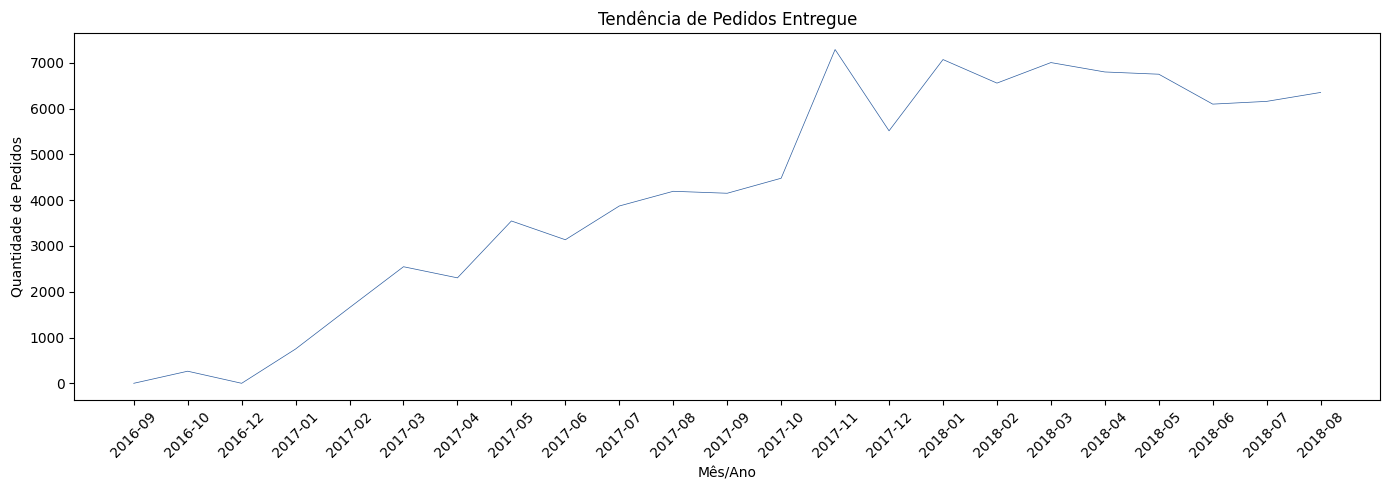

In [33]:
from matplotlib.lines import lineMarkers
# Agora é o gráfico
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.figure(figsize=(14,5))
sns.lineplot(data=tendencia_pedidos, x='ano_mes_compra', y='id_pedido', markers='o', color='#2b5c9f', linewidth=0.5)
plt.title('Tendência de Pedidos Entregue')
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Pergunta 2 - Como o custo médio do frete varia geograficamente pelo Brasil?


In [35]:
# Aqui pedi para a IA do Google gerar esse mapa, segue o prompt:
# quero um mapa_regioes do brasil de forma que todos os estados identificados em duas letras indique qual região é, ex: 'AM': Norte', 'AP': 'Norte'

mapa_regioes = {
    'AC': 'Norte', 'AL': 'Nordeste', 'AM': 'Norte', 'AP': 'Norte',
    'BA': 'Nordeste', 'CE': 'Nordeste', 'DF': 'Centro-Oeste', 'ES': 'Sudeste',
    'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MG': 'Sudeste', 'MS': 'Centro-Oeste',
    'MT': 'Centro-Oeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PE': 'Nordeste',
    'PI': 'Nordeste', 'PR': 'Sul', 'RJ': 'Sudeste', 'RN': 'Nordeste',
    'RO': 'Norte', 'RR': 'Norte', 'RS': 'Sul', 'SC': 'Sul',
    'SE': 'Nordeste', 'SP': 'Sudeste', 'TO': 'Norte'
}

df_main['regiao_brasil'] = df_main['estado_cliente'].map(mapa_regioes)

# Gemini mostrando seu valor!!!

In [36]:
# Criando o frete por região
frete_regiao = df_main.groupby('regiao_brasil')['valor_frete'].mean().reset_index()
frete_regiao = frete_regiao.sort_values(by='valor_frete', ascending=False)


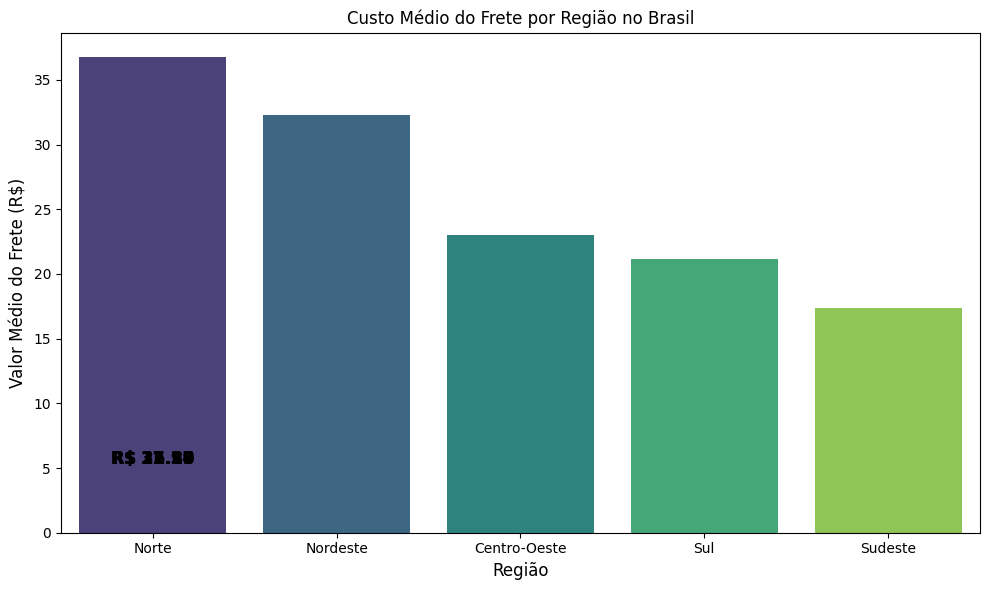

In [41]:
# Agora é o gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='regiao_brasil', y='valor_frete', data=frete_regiao, hue='regiao_brasil', palette='viridis')
plt.title('Custo Médio do Frete por Região no Brasil')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Valor Médio do Frete (R$)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0,5))

plt.tight_layout()
plt.show()


/tmp/ipykernel_318/2736865368.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='faixa_atraso', y='nota_avaliacao', data=impacto_nota, palette='viridis')


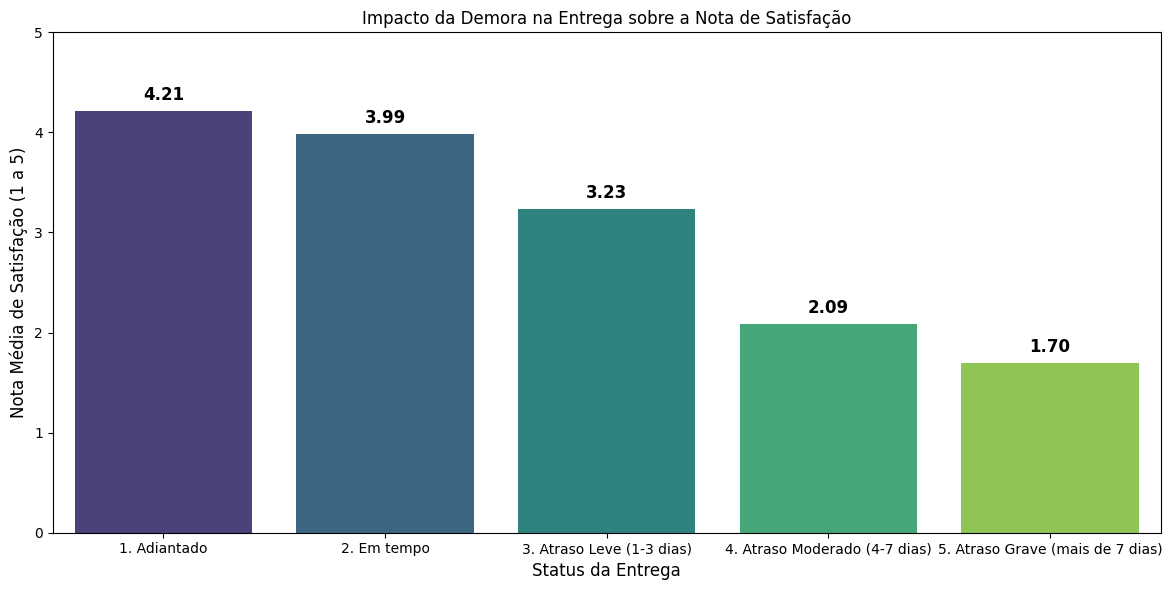

In [46]:
# Pergunta 3
# Qual é o impacto real e quantificável da demora na entrega sobre a nota de satisfação do cliente?

def categoriar_atraso(dias):
    if dias < 0:
      return '1. Adiantado'
    elif dias == 0:
      return '2. Em tempo'
    elif 1 <= dias <= 3:
      return '3. Atraso Leve (1-3 dias)'
    elif 4 <= dias <= 7:
      return '4. Atraso Moderado (4-7 dias)'
    else:
      return '5. Atraso Grave (mais de 7 dias)'

df_main['faixa_atraso'] = df_main['atrazo_entrega_dias'].apply(categoriar_atraso)

impacto_nota = df_main.groupby('faixa_atraso')['nota_avaliacao'].mean().reset_index()

plt.figure(figsize=(12,6))
ax = sns.barplot(x='faixa_atraso', y='nota_avaliacao', data=impacto_nota, palette='viridis')
plt.title('Impacto da Demora na Entrega sobre a Nota de Satisfação')
plt.xlabel('Status da Entrega', fontsize=12)
plt.ylabel('Nota Média de Satisfação (1 a 5)', fontsize=12)
plt.ylim(0,5)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0,5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Pergunta 4
# Quais categorias de produto do catálogo mais puxam a satisfação para baixo e sofrem com a complexidade logística?

# Performance de Catalogo vs Frete

volume_categoria = df_main['categoria_produto'].value_counts()
categorias_relevantes = volume_categoria[volume_categoria > 100].index

# Apenas Categorias relevantes, com mais de 100 pedidos

df_categorias = df_main[df_main['categoria_produto'].isin(categorias_relevantes)]

# Agrupando a nota média e o frete por categoria
